In [1]:
'''
import statements to load bert, codet5 transformers and Random Forest machine learning classes
'''
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import AutoTokenizer, AutoModel
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt   
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

W1026 05:16:15.599000 5852 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
#loading & displaying source code errors dataset
dataset = pd.read_csv("Dataset/SourceCodeError.csv", usecols=['original_src', 'error'])
dataset

,original_src,error
0,while True:\n try:\n input_line = in...,IndexError: list index out of range
1,while True:\n g = int(input())\n now = 5...,EOFError: EOF when reading a line
2,"result = [0] * 3\nwhile 1:\n a, b, c = sort...",EOFError: EOF when reading a line
3,"x = input()\nwhile x:\n a, b = x.split("" "")...",TLE
4,"import collections\n\nwhile True:\n N, Q = ...",0
...,...,...
1452,# -*- coding: utf-8 -*-\n\n\ndef main():\n ...,0
1453,"H, W = map(int, input().split())\nG = [list(ma...",0
1454,import sys\n\nsys.setrecursionlimit(10**6)\nIN...,0
1455,"def solve(string):\n ins = string.split(""\n...",0


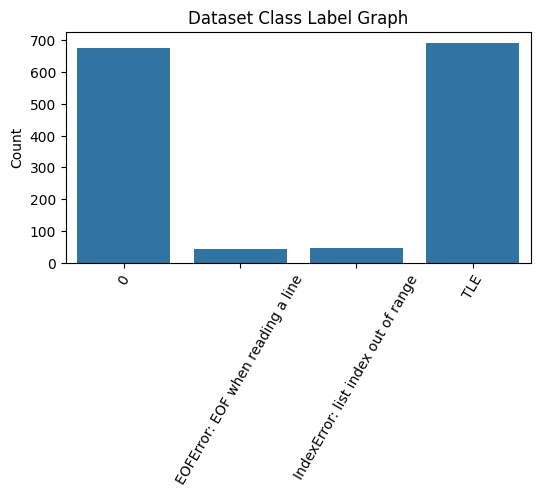

In [4]:
#finding & plotting graph of differentsource code errors available in dataset
labels, count = np.unique(dataset['error'].ravel(), return_counts = True)
plt.figure(figsize = (6, 3)) 
sns.barplot(x = labels, y=count)
plt.title("Dataset Class Label Graph")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.show()

In [6]:
#function to get errors details as numeric label
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i].strip().lower() == name:
            index = i
            break
    return index

In [8]:
#loop each source code and identify class labels as dataset processing and then load codet5 vector
import os
if os.path.exists("model/X.npy"):#loading processed source code and errort5 embedding
    X = np.load("model/X.npy")
    Y = np.load("model/Y.npy")
    codet5 = np.load("model/codet5.npy")
else:
    X = []
    Y = []
    code = dataset['original_src'].ravel()#get source code and error details from dataset
    names = dataset['error'].ravel()
    for i in range(len(code)):#loop each source code
        data = code[i]
        label = getLabel(names[i].strip().lower())#get numeric label for given error
        X.append(data)#create array with all errors and source code
        Y.append(label)
    X = np.asarray(X)
    Y = np.asarray(Y)
    np.save("model/X", X)#save processed data for future loading
    np.save("model/Y", Y)    
print("Dataset Processing Completed")
print("Total source codes found in Dataset = "+str(X.shape[0]))

Dataset Processing Completed
Total source codes found in Dataset = 1457


In [96]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(codet5, Y[0:100], test_size=0.2)
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data
print("Dataset Train & Test Split Process Completed")

Dataset Train & Test Split Process Completed


In [97]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [98]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict):
    p = round(precision_score(testY, predict,average='macro') * 100, 2)
    r = round(recall_score(testY, predict,average='macro') * 100, 2)
    f = round(f1_score(testY, predict,average='macro') * 100, 2)
    a = round(accuracy_score(testY,predict)*100, 2)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=3)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=3)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

CodeT5 Decision Tree Accuracy  : 70.0
CodeT5 Decision Tree Precision : 50.69
CodeT5 Decision Tree Recall    : 63.93
CodeT5 Decision Tree FSCORE    : 55.09


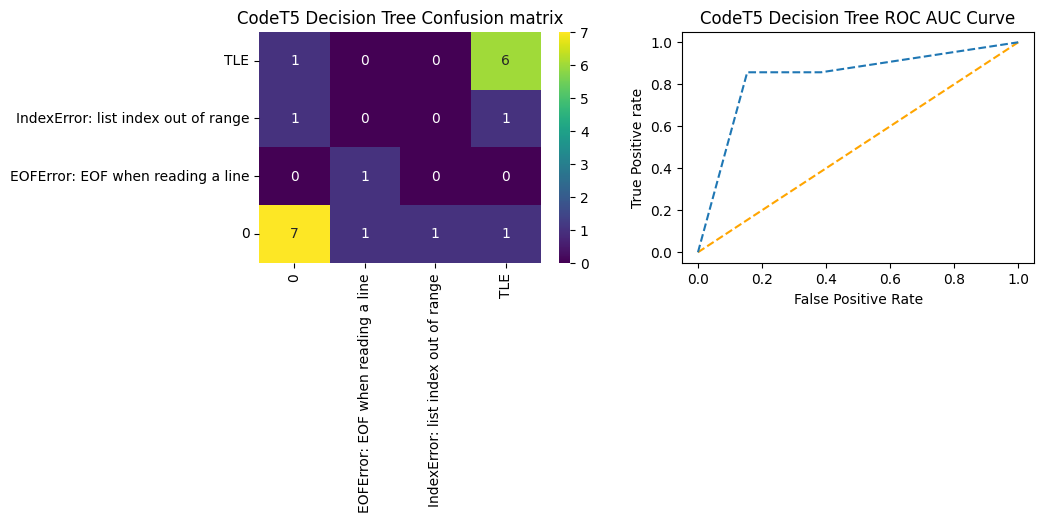

In [99]:
#training existing decision tree algorithm using codet5 embedding
from sklearn.tree import DecisionTreeClassifier
dt_cls = DecisionTreeClassifier()
dt_cls.fit(X_train, y_train)
predict = dt_cls.predict(X_test)
modelEvaluation("CodeT5 Decision Tree", y_test, predict)

CodeT5 Random Forest Accuracy  : 75.0
CodeT5 Random Forest Precision : 37.09
CodeT5 Random Forest Recall    : 42.86
CodeT5 Random Forest FSCORE    : 39.6


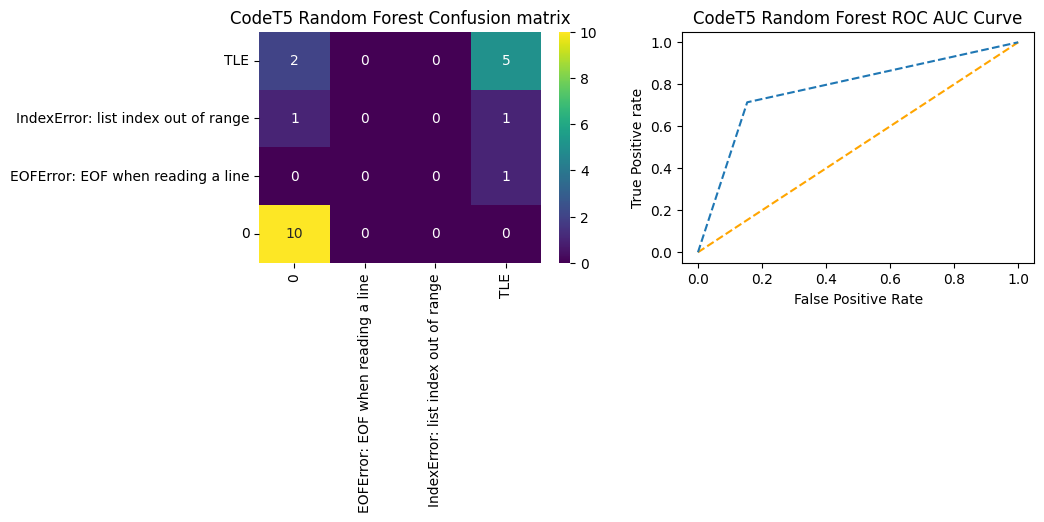

In [100]:
#training existing Random Forest algorithm using codet5 embedding
from sklearn.ensemble import RandomForestClassifier
rf_cls = RandomForestClassifier()
rf_cls.fit(X_train, y_train)
predict = rf_cls.predict(X_test)
modelEvaluation("CodeT5 Random Forest", y_test, predict)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Propose Bert_Cased Accuracy  : 92.12
Propose Bert_Cased Precision : 93.21
Propose Bert_Cased Recall    : 77.9
Propose Bert_Cased FSCORE    : 83.15


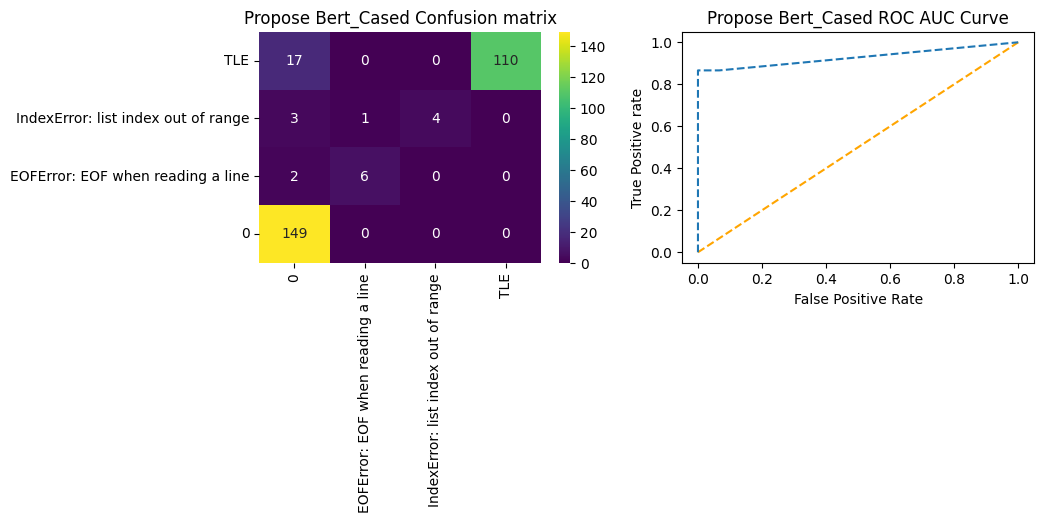

In [105]:
#training propose BERT cased model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
bert_model = BertForSequenceClassification.from_pretrained('bert-base-cased', num_labels=4) # num_labels depends on your classification task
encoded_data = bert_tokenizer.batch_encode_plus(X, add_special_tokens=True, return_attention_mask=True, padding='max_length', max_length=128,
                                           truncation=True, return_tensors='pt')
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']
labels_tensor = torch.tensor(Y)
# Split data into training and validation sets.
dataset = TensorDataset(input_ids, attention_masks, labels_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
optimizer = Adam(bert_model.parameters(), lr=1e-5)
bert_tokenizer = BertTokenizer.from_pretrained("model/Bert")
bert_model = BertForSequenceClassification.from_pretrained("model/Bert", num_labels=4) # num_labels depends on your classification task
#perform prediction on test data
bert_model.to(device)
bert_model.eval()
predictions, true_labels = [], []
for batch in val_dataloader:
    b_input_ids, b_attention_mask, b_labels = tuple(t.to(device) for t in batch)
    with torch.no_grad():
        outputs = bert_model(b_input_ids, attention_mask=b_attention_mask)
    logits = outputs.logits
    preds = torch.argmax(logits, dim=1).flatten()
    predictions.extend(preds.cpu().numpy())
    true_labels.extend(b_labels.cpu().numpy())
#call this function to calculate accuracy and other metrics
modelEvaluation("Propose Bert_Cased", true_labels, predictions)    

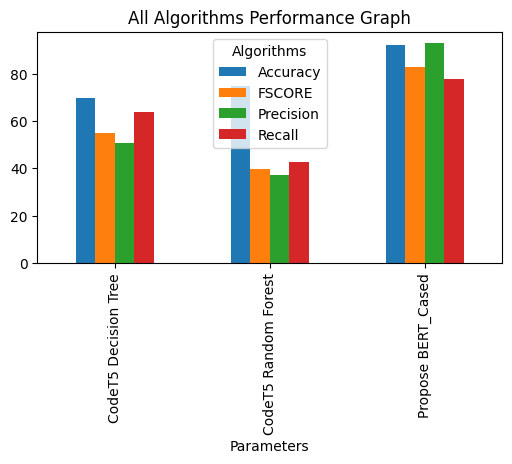

In [106]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['CodeT5 Decision Tree','Accuracy',accuracy[0]],['CodeT5 Decision Tree','Precision',precision[0]],['CodeT5 Decision Tree','Recall',recall[0]],['CodeT5 Decision Tree','FSCORE',fscore[0]],
                   ['CodeT5 Random Forest','Accuracy',accuracy[1]],['CodeT5 Random Forest','Precision',precision[1]],['CodeT5 Random Forest','Recall',recall[1]],['CodeT5 Random Forest','FSCORE',fscore[1]],
                   ['Propose BERT_Cased','Accuracy',accuracy[2]],['Propose BERT_Cased','Precision',precision[2]],['Propose BERT_Cased','Recall',recall[2]],['Propose BERT_Cased','FSCORE',fscore[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot(index="Parameters", columns="Algorithms", values="Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [107]:
#display all algorithm performnace
algorithms = ['CodeT5 Decision Tree', 'CodeT5 Random Forest', 'Propose Bert_Cased']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,CodeT5 Decision Tree,70.00,50.69,63.93,55.09
1,CodeT5 Random Forest,75.00,37.09,42.86,39.60
2,Propose Bert_Cased,92.12,93.21,77.90,83.15


In [110]:
#loading test data and then classifying source code error
testData = pd.read_csv("Dataset/testData.csv")
testData = testData.values
data = []
for i in range(len(testData)):
    value = testData[i,0].strip()
    data.append(value)
#apply bert encoding to get vector    
encoded_new_data = bert_tokenizer.batch_encode_plus(data, add_special_tokens=True, return_attention_mask=True, padding='max_length', max_length=128,
                                                     truncation=True, return_tensors='pt')
new_input_ids = encoded_new_data['input_ids'].to(device)
new_attention_masks = encoded_new_data['attention_mask'].to(device)
bert_model.eval()
with torch.no_grad():
    outputs = bert_model(new_input_ids, attention_mask=new_attention_masks)#apply propose bert model for classification
predictions = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy() 
for i in range(len(predictions)):
    print("Test Source Code = "+str(testData[i,0]))
    print("Classified Source Code Error ====> "+labels[predictions[i]])
    print()

Test Source Code = while True:
    try:
        input_line = input()
        if input_line == "":
            break
        else:
            nums = list(map(int, input_line.split()))
            max_num = max(nums)
            nums.remove(max_num)
            if max_num**2 == nums[0] ** 2 + nums[1] ** 2:
                print("YES")
            else:
                print("NO")
    except EOFError:
        break

Classified Source Code Error ====> EOFError: EOF when reading a line

Test Source Code = while True:
    g = int(input())
    now = 512
    ans = []
    while True:
        if g == 0:
            break
        elif g >= now:
            g -= now
            ans.append(now)
        now //= 2
    temp = ""
    for i in ans[::-1]:
        temp += str(i) + " "
    print(temp[:-1])

Classified Source Code Error ====> EOFError: EOF when reading a line

Test Source Code = result = [0] * 3
while 1:
    a, b, c = sorted(list(map(int, input().split())))
    if a + b > c:
        flag =